# ARTI 308 – Lab 6: Linear Regression
## Predicting Purchase Amount using Customer Shopping Behavior Dataset

### Objective
In this lab, we will perform Linear Regression to predict a continuous variable. Using the customer shopping behavior dataset, we will predict the `Purchase Amount (USD)` based on numerical features and engineered categorical features.

Steps:
1. Load the dataset into a DataFrame
2. Explore the data (head, info, describe)
3. Apply feature engineering (One-Hot Encoding categorical features)
4. Prepare the data for modeling (Train/Test Split)
5. Train a Linear Regression model
6. Evaluate the model performance (MAE, MSE, RMSE)

## 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline
sns.set(style="whitegrid")

## 2. Load and Explore the Dataset

In [2]:
df = pd.read_csv('shopping_behavior_updated (1).csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Discount Applied        3900 non-null   object 
 13  Previous Purchases      3900 non-null   int64  
 14  Payment Method          3900 non-null   

In [4]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


## 3. Exploratory Data Analysis (EDA)
Let's create a pairplot for the continuous/numeric features to see their distributions.

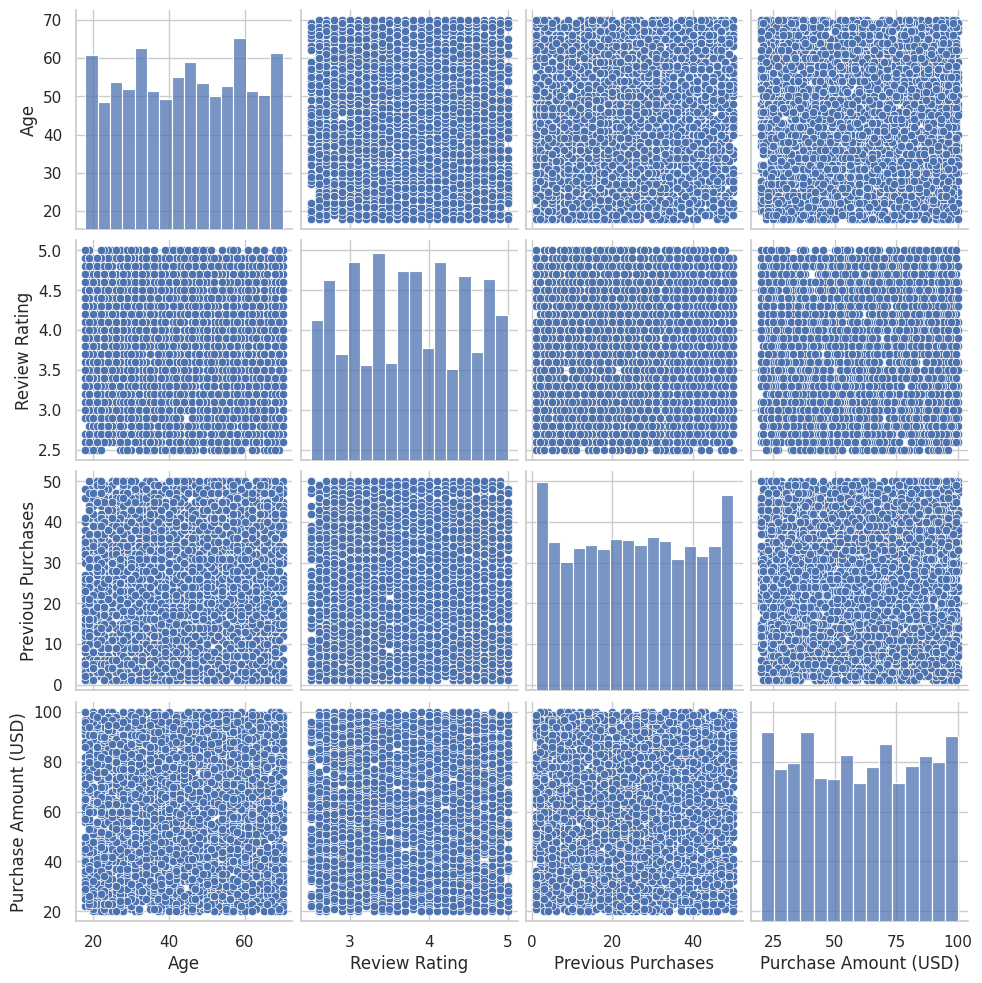

In [5]:
sns.pairplot(df[['Age', 'Review Rating', 'Previous Purchases', 'Purchase Amount (USD)']])
plt.show()

## 4. Feature Engineering and Preparation
Linear regression requires numerical inputs. We will encode categorical columns like `Gender`, `Category`, and `Season` using dummy variables.

In [6]:
# Encode categorical features
categorical_cols = ['Gender', 'Category', 'Season', 'Subscription Status', 'Discount Applied']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Combine our numeric base features with the new dummy variables
base_numeric = ['Age', 'Review Rating', 'Previous Purchases']
dummy_features = [col for col in df_encoded.columns if any(prefix in col for prefix in
                 ['Gender_', 'Category_', 'Season_', 'Subscription Status_', 'Discount Applied_'])]

X = df_encoded[base_numeric + dummy_features]
y = df_encoded['Purchase Amount (USD)']

X.head()

,Age,Review Rating,Previous Purchases,Gender_Male,Category_Clothing,Category_Footwear,Category_Outerwear,Season_Spring,Season_Summer,Season_Winter,Subscription Status_Yes,Discount Applied_Yes
0,55,3.1,14,True,True,False,False,False,False,True,True,True
1,19,3.1,2,True,True,False,False,False,False,True,True,True
2,50,3.1,23,True,True,False,False,True,False,False,True,True
3,21,3.5,49,True,False,True,False,True,False,False,True,True
4,45,2.7,31,True,True,False,False,True,False,False,True,True


## 5. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

## 6. Train the Linear Regression Model

In [8]:
lm = LinearRegression()
lm.fit(X_train, y_train)

# Check out the coefficients
print("Model Intercept:", lm.intercept_)

Model Intercept: 58.855707505869006


## 7. Model Evaluation
Let's predict on the test set and calculate MAE, MSE, and RMSE.

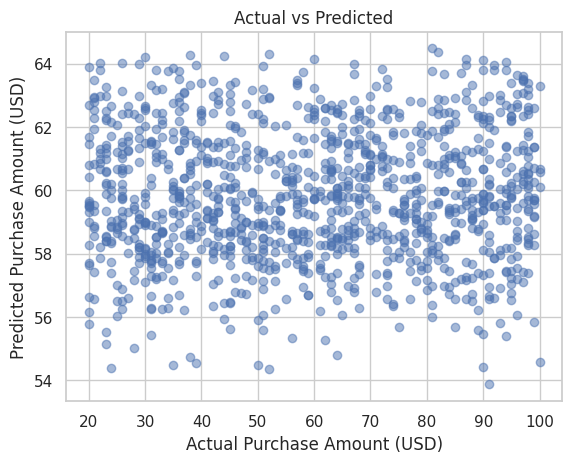

In [9]:
predictions = lm.predict(X_test)

plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel('Actual Purchase Amount (USD)')
plt.ylabel('Predicted Purchase Amount (USD)')
plt.title('Actual vs Predicted')
plt.show()

In [10]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 20.6047880809405
MSE: 567.0748136865449
RMSE: 23.813332687520763
